C:\Users\Admin\AppData\Local\Temp\ipykernel_392\1490480762.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download(
[*********************100%***********************]  3 of 3 completed
C:\Users\Admin\AppData\Local\Temp\ipykernel_392\1490480762.py:85: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


===Price Data===
Ticker      HDFCBANK.NS  ICICIBANK.NS  KOTAKBANK.NS
Date                                               
2024-01-01   826.441040    983.282715    380.972717
2024-01-02   826.927734    966.409241    372.172516
2024-01-03   814.176575    968.180298    372.342133
2024-01-04   822.912537    971.230286    371.883179
2024-01-05   818.702698    977.674622    368.690338
Shape: (246, 3)

===Daily Returns===
Ticker      HDFCBANK.NS  ICICIBANK.NS  KOTAKBANK.NS
Date                                               
2024-01-02     0.000589     -0.017160     -0.023099
2024-01-03    -0.015420      0.001833      0.000456
2024-01-04     0.010730      0.003150     -0.001233
2024-01-05    -0.005116      0.006635     -0.008586
2024-01-08    -0.011146     -0.011774     -0.011637
Ticker
HDFCBANK.NS    -0.020920
ICICIBANK.NS   -0.017460
KOTAKBANK.NS   -0.019368
Name: 0.05, dtype: float64
Ticker
HDFCBANK.NS    -20919.835951
ICICIBANK.NS   -17460.158119
KOTAKBANK.NS   -19368.241202
Name: 0.05, dty

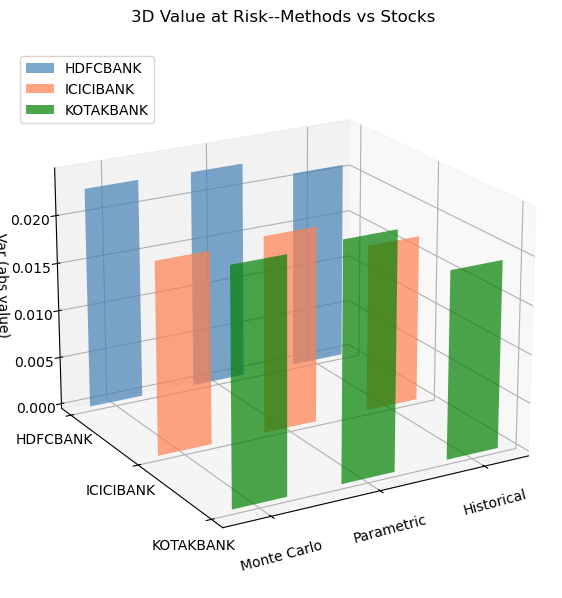

In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data=yf.download(
    ["HDFCBANK.NS","ICICIBANK.NS","KOTAKBANK.NS"],
    start="2024-01-01",
    end="2025-01-01"
)
prices=data["Close"]
print("===Price Data===")
print(prices.head())
print("Shape:", prices.shape)
returns=prices.pct_change(fill_method=None)
returns=returns.dropna()
print("\n===Daily Returns===")
print(returns.head())

var_95=returns.quantile(0.05)
print(var_95)

investment=1_000_000
print(var_95*investment)

mean=returns.mean()
std=returns.std()
var_parametric=mean-1.645*std
print("var parametric:", var_parametric)

simulated=np.random.normal(
    mean["HDFCBANK.NS"],
    std["HDFCBANK.NS"],
    10000
)
var_mc=np.percentile(simulated, 5)
print(f"Monte Carlo Var HDFCBANK: {var_mc:.4f}")

np.random.seed(42)
stocks=["HDFCBANK.NS", "ICICIBANK.NS", "KOTAKBANK.NS"]
var_mc_all={}

for stock in stocks:
    simulated=np.random.normal(mean[stock], std[stock], 10000)
    var_mc_all[stock]=np.percentile(simulated, 5)

print(var_mc_all)

from mpl_toolkits.mplot3d import Axes3D

methods=["Historical", "Parametric", "Monte Carlo"]
stocks=["HDFCBANK", "ICICIBANK", "KOTAKBANK"]

var_data=[
    [var_95["HDFCBANK.NS"], var_parametric["HDFCBANK.NS"], var_mc_all["HDFCBANK.NS"]],
    [var_95["ICICIBANK.NS"], var_parametric["ICICIBANK.NS"], var_mc_all["ICICIBANK.NS"]],
    [var_95["KOTAKBANK.NS"], var_parametric["KOTAKBANK.NS"], var_mc_all["KOTAKBANK.NS"]]
]

fig=plt.figure(figsize=(12, 7))
ax=fig.add_subplot(111, projection="3d")

colors=["steelblue", "coral", "green"]
x_pos=np.arange(len(methods))
y_pos=np.arange(len(stocks))

for i, (stock, color) in enumerate(zip(stocks, colors)):
    ax.bar(x_pos,
           np.abs(var_data[i]),
           zs=i,
           zdir="y",
           width=0.5,
           color=color,
           alpha=0.7,
           label=stock)

ax.set_title("3D Value at Risk--Methods vs Stocks", pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(methods, rotation=15)
ax.set_yticks(y_pos)
ax.set_yticklabels(stocks)
ax.set_zlabel("Var (abs value)")
ax.legend(loc="upper left")
ax.view_init(elev=20, azim=60)
plt.tight_layout()
plt.show()


    